# Lung Radar: Revolutionizing Lung Cancer Diagnostics with AI and Deep Learning

## Lung Cancer CT Scans Dataset
**Dataset Description**
The dataset consists of CT scan images categorized into four distinct classes: `adenocarcinoma`, `large.cell`, `normal`, and `squamous`. Each category corresponds to different types of lung cancer or normal tissue, captured via CT scan imaging.

**Class Breakdown**:
- Adenocarcinoma (adenocarcinoma): A subtype of non-small cell lung cancer (NSCLC), often found in the outer parts of the lungs.
- Large Cell (large.cell): Refers to large cell carcinoma, a subtype of NSCLC that tends to grow quickly.
- Normal (normal): Represents healthy, non-cancerous tissue used as a baseline comparison.
- Squamous Cell (squamous): Another subtype of NSCLC, typically associated with the central airways in the lungs.

## 1. Data Exploration
Data exploration is essential for:

- Gaining an understanding of the data’s structure, quality, and patterns.
- Deciding on the appropriate preprocessing steps.
- Identifying potential issues that could impact modeling, such as missing values, outliers, and class imbalance.
- Selecting the most appropriate machine learning models and techniques.
- Improving model performance and ensuring better generalization.

### 1.1 Import all libraries
All libraries to be used during preprocessing are imported here.

In [1]:
import os
import numpy as np
import cv2  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from skimage import exposure
from imblearn.over_sampling import RandomOverSampler
from scipy.ndimage import zoom, gaussian_filter
import glob
from skimage.filters import threshold_otsu
import random
import tensorflow as tf
tf.config.set_visible_devices([], 'Cuda')


2024-11-26 09:28:36.280944: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 09:28:36.363033: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 09:28:36.423626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732602516.483578    4617 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732602516.503570    4617 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-26 09:28:36.650794: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

### 1.2 Load the dataset
Load the dataset to see the number of images in the dataset. The number of images are 11,516 with 4 unique value labels.The labels are derived from the folder names: `adenocarcinoma`, `large.cell`, `normal`, and `squamous`.

In [2]:
# Define the path to the dataset
data_path = '/home/sharon/Documents/machine_learning/Lung_Cancer_CT_Scans'

# Initialize lists to store images and labels
images = []
labels = []

# Define class labels and corresponding folders
class_names = ['adenocarcinoma', 'large-cell', 'normal', 'squamous']
label_dict = {class_name: idx for idx, class_name in enumerate(class_names)}

# Load images and labels from folders
missing_labels = 0  # Counter for images without labels
for class_name in class_names:
    folder_path = os.path.join(data_path, class_name)
    if os.path.isdir(folder_path):  # Check if the class folder exists
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            if img_path.endswith('.png') or img_path.endswith('.jpg'):
                # Load the image
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
                if img is not None:  # Ensure the image is loaded successfully
                    img = cv2.resize(img, (256, 256))  # Resize to standard dimensions (optional)
                    images.append(img)
                    labels.append(label_dict[class_name])
                else:
                    print(f"Warning: Failed to load {img_path}")
                    missing_labels += 1
            else:
                print(f"Skipped non-image file: {img_path}")
    else:
        print(f"Warning: Folder not found for class '{class_name}'")

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Display final counts and check if every image has a label
print(f"Loaded {len(images)} images with {len(np.unique(labels))} unique labels.")
print(f"Total images without labels: {missing_labels}")


Loaded 11516 images with 4 unique labels.
Total images without labels: 0


### 1.3 Visualize Random images
Display random images to check handwriting styles and data variety (for CT scans, these images will vary based on the cancer type).

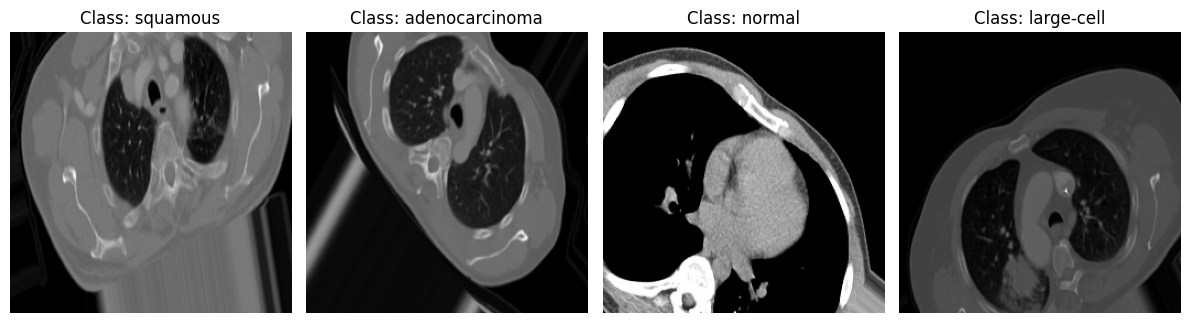

In [3]:
# Updated function to display one random image from each class
def plot_random_images(images, labels, class_names):
    unique_labels = np.unique(labels)
    n_images = len(unique_labels)  # Ensure we only display one per class
    
    plt.figure(figsize=(12, 6))
    displayed_classes = set()  # Track the classes already displayed

    for i in range(n_images):
        # Ensure one image from each class
        while True:
            random_idx = np.random.choice(len(images))
            label = labels[random_idx]
            if label not in displayed_classes:  # Check if this class is already displayed
                displayed_classes.add(label)
                break
        
        image = images[random_idx]
        plt.subplot(1, n_images, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Class: {class_names[label]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Call the function with images, labels, and class_names
plot_random_images(images, labels, class_names)

### 1.4 Inspect Dataset Structure, Size, and Labels
Examine the number of images per class to see if there is any class imbalance and inspect the first few images.
- adenocarcinoma: 3560 images
- large-cell: 2232 images
- normal: 2795 images
- squamous: 2907 images

Class distribution:
adenocarcinoma: 3560 images
large-cell: 2254 images
normal: 2795 images
squamous: 2907 images


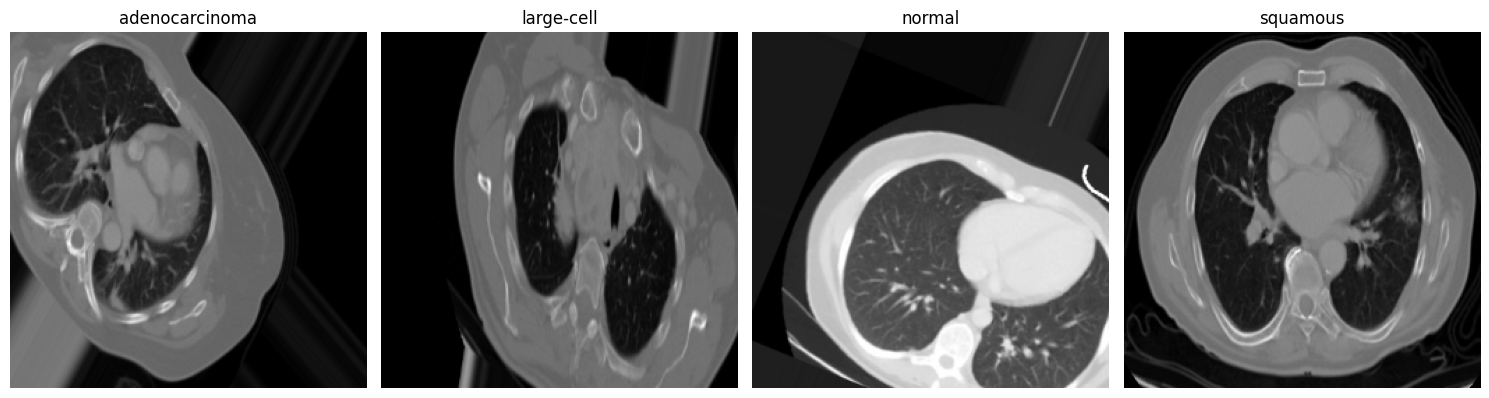

In [4]:
#  Check the distribution of class labels
unique, counts = np.unique(labels, return_counts=True)
print("Class distribution:")
for cls, count in zip(unique, counts):
    print(f"{class_names[cls]}: {count} images")

# Dynamically create subplots based on the number of classes
fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5))

# Visualize the first available image of each class
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]
    if len(class_images) > 0:  # Ensure there is at least one image in this class
        axes[i].imshow(class_images[0], cmap='gray')
        axes[i].set_title(f"{class_name}")
    else:
        axes[i].text(0.5, 0.5, "No images", ha='center', va='center')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 1.5 Class Distribution Analysis
Plot the histogram to check the balance of images in each class. This will help you identify if there is an imbalance, which may need to be addressed later.


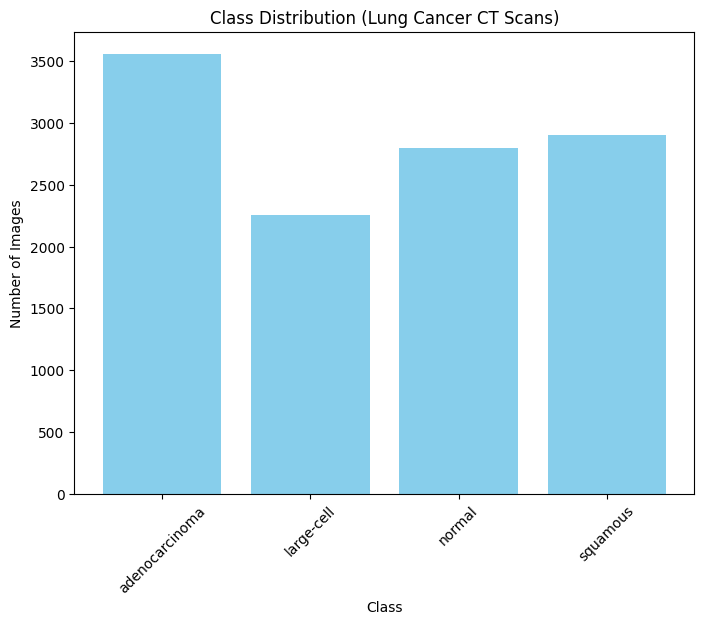

In [5]:
# Plot the class distribution histogram
plt.figure(figsize=(8, 6))
plt.bar(class_names, counts, color='skyblue')
plt.title('Class Distribution (Lung Cancer CT Scans)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

### 1.6  Image Intensity Analysis
Calculate the basic statistics (mean, standard deviation) of pixel intensities across the images to check if there are any unusual brightness or contrast issues.

- **Mean Intensity** of 77.89 tells you that, on average, the image is on the darker side, but not very close to black.
- **Standard Deviation** of 70.21 indicates that there is a high level of intensity variation within the image, suggesting a contrasty image with significant differences between lighter and darker areas.

Intensity Statistics per Class:
adenocarcinoma: Mean Intensity = 77.31, Standard Deviation = 64.22
large-cell: Mean Intensity = 58.97, Standard Deviation = 53.87
normal: Mean Intensity = 107.84, Standard Deviation = 90.71
squamous: Mean Intensity = 64.27, Standard Deviation = 54.56


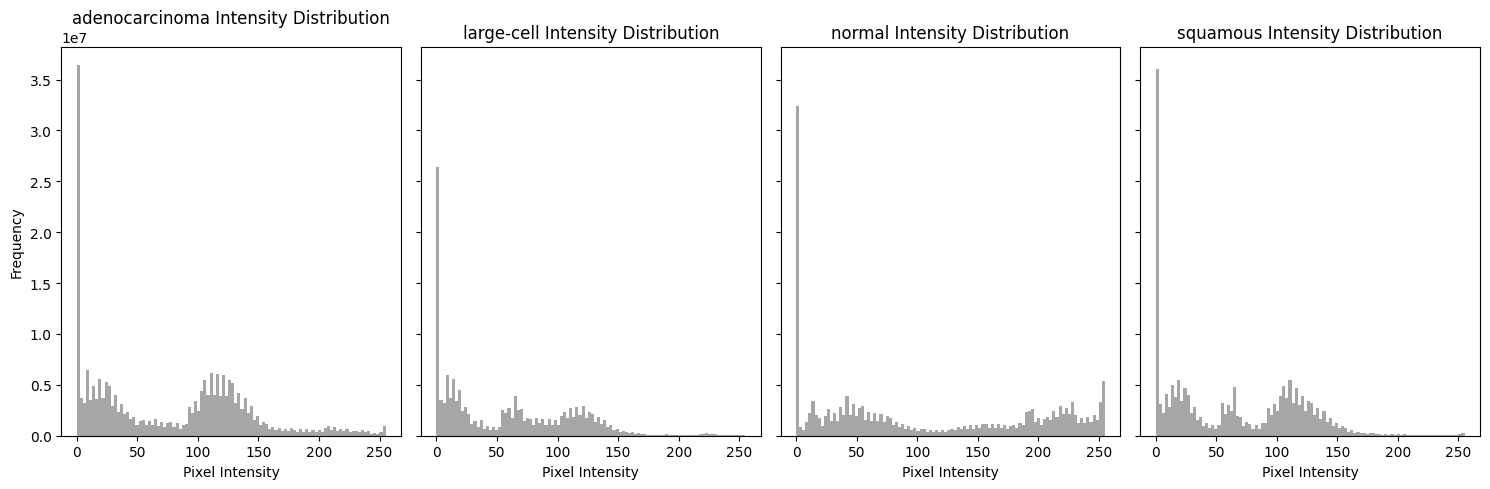

In [6]:
# Initialize dictionaries to store intensity stats for each class
mean_intensities = {}
std_intensities = {}

# Calculate intensity statistics for each class
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]  # Select images for the current class
    if class_images.size > 0:  # Ensure there are images in the class
        class_flattened = class_images.flatten()
        mean_intensities[class_name] = np.mean(class_flattened)
        std_intensities[class_name] = np.std(class_flattened)
    else:
        mean_intensities[class_name] = None
        std_intensities[class_name] = None
        print(f"Warning: No images found for class '{class_name}'")

# Print mean and standard deviation for each class
print("Intensity Statistics per Class:")
for class_name in class_names:
    mean = mean_intensities[class_name]
    std = std_intensities[class_name]
    print(f"{class_name}: Mean Intensity = {mean:.2f}, Standard Deviation = {std:.2f}")

# Plot intensity distributions for each class
fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5), sharey=True)
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]
    if class_images.size > 0:  # Only plot if there are images in this class
        class_flattened = class_images.flatten()
        axes[i].hist(class_flattened, bins=100, color='gray', alpha=0.7)
        axes[i].set_title(f"{class_name} Intensity Distribution")
        axes[i].set_xlabel('Pixel Intensity')
    else:
        axes[i].text(0.5, 0.5, "No images", ha='center', va='center')
    axes[i].set_ylabel('Frequency' if i == 0 else "")

plt.tight_layout()
plt.show()

### 1.7 Noise and Quality Check
Visually inspect images with extreme pixel intensity values (i.e., overly bright or dark images), as they could indicate poor quality or noisy data.

adenocarcinoma: 2849 noisy images detected
large-cell: 1216 noisy images detected
normal: 2795 noisy images detected
squamous: 1609 noisy images detected


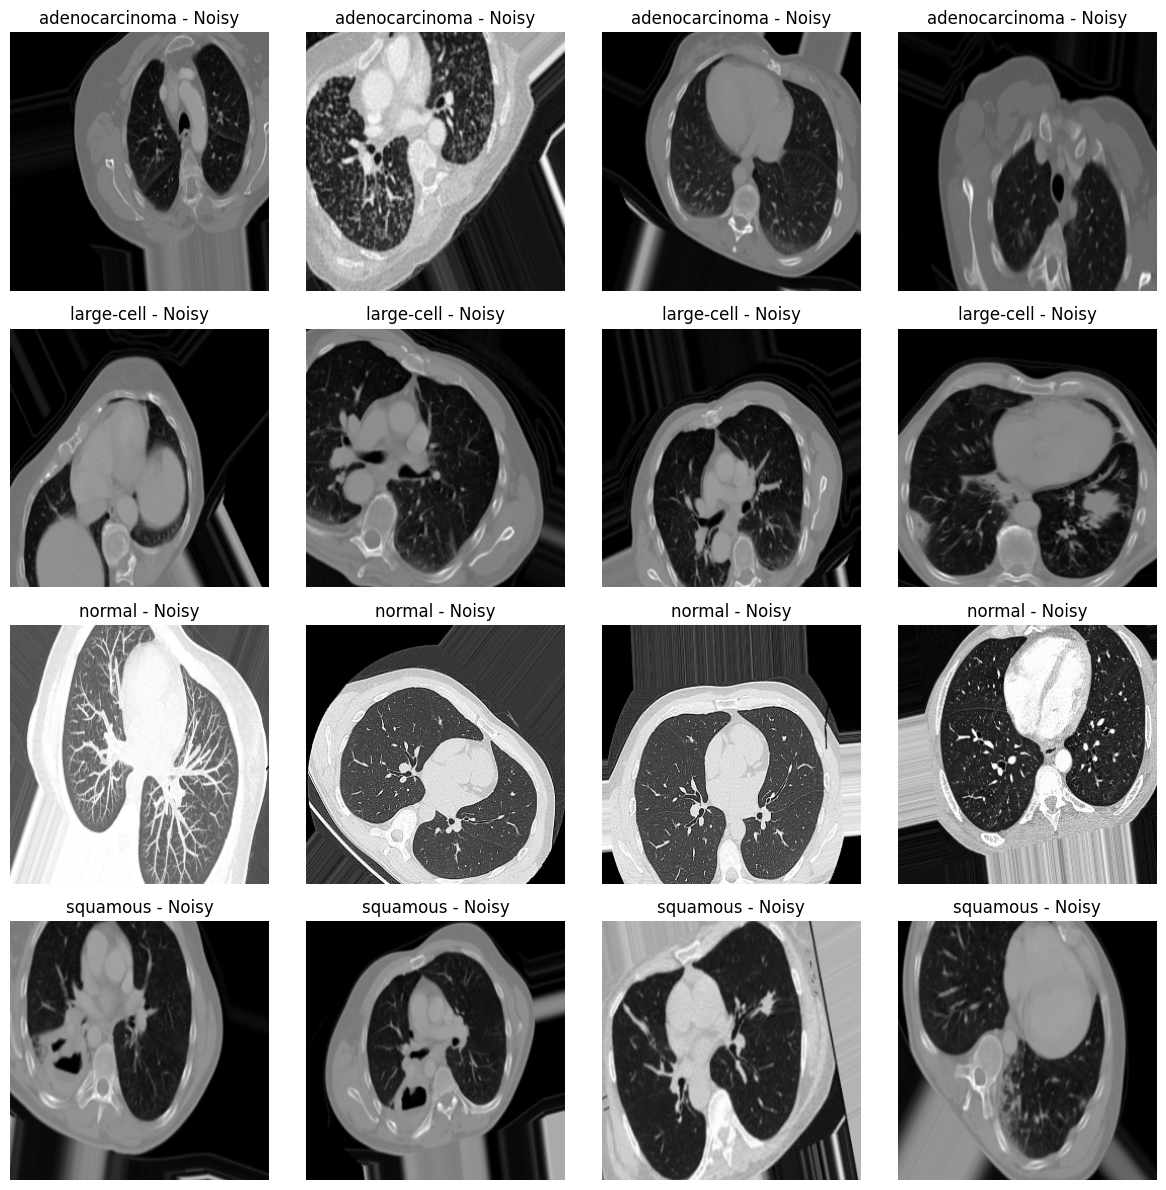

In [7]:
# Define threshold for detecting noisy images (adjust as needed)
noise_threshold = 50

# Track noisy images by class
noisy_images_per_class = {class_name: [] for class_name in class_names}

# Identify noisy images in each class
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]
    if class_images.size > 0:  # Ensure there are images in the class
        # Calculate the standard deviation for each image in the class
        variances = np.std(class_images, axis=(1, 2))
        noisy_indices = np.where(variances > noise_threshold)[0]
        
        # Store the indices of noisy images for the current class
        noisy_images_per_class[class_name] = noisy_indices
        print(f"{class_name}: {len(noisy_indices)} noisy images detected")

# Visualize a few noisy images per class
def plot_noisy_images(images, labels, noisy_images_per_class, n_images=4):
    fig, axes = plt.subplots(len(class_names), n_images, figsize=(12, len(class_names) * 3))
    for i, class_name in enumerate(class_names):
        noisy_indices = noisy_images_per_class[class_name]
        if len(noisy_indices) > 0:
            # Randomly select a few noisy images from this class
            selected_indices = np.random.choice(noisy_indices, min(n_images, len(noisy_indices)), replace=False)
            for j, idx in enumerate(selected_indices):
                axes[i, j].imshow(images[labels == i][idx], cmap='gray')
                axes[i, j].set_title(f"{class_name} - Noisy")
                axes[i, j].axis('off')
        else:
            # If no noisy images, leave blank
            for j in range(n_images):
                axes[i, j].axis('off')
                axes[i, j].text(0.5, 0.5, "No noisy image", ha='center', va='center')

    plt.tight_layout()
    plt.show()

plot_noisy_images(images, labels, noisy_images_per_class, n_images=4)

### 1.8 Shape and Format Consistency Check
Ensure all images are of consistent shape (e.g., 256x256 pixels after resizing) and in the expected format.


In [8]:
# Check if all images in each class are of the same shape (256x256)
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]
    shapes = [image.shape for image in class_images]
    
    if all(shape == (256, 256) for shape in shapes):
        print(f"All images in '{class_name}' are of consistent shape (256x256).")
    else:
        inconsistent_shapes = [shape for shape in shapes if shape != (256, 256)]
        print(f"Inconsistent image shapes found in '{class_name}': {inconsistent_shapes}")


All images in 'adenocarcinoma' are of consistent shape (256x256).
All images in 'large-cell' are of consistent shape (256x256).
All images in 'normal' are of consistent shape (256x256).
All images in 'squamous' are of consistent shape (256x256).


## 2. Data Preprocessing
Objective: Prepare the images for model training by ensuring uniformity and enhancing data quality.

### 2.1 Normalization of the different classes
Different techniques were used for the different cells. Here is a breakdown for each technique chosen: 
1. **CLAHE for Adenocarcinoma** (Contrast Limited Adaptive Histogram Equalization)
- Use Case: Similar to histogram equalization but particularly useful if images contain both high-contrast and low-contrast regions.
- Description: Applies adaptive histogram equalization with a limit on contrast enhancement to prevent noise amplification.
- This technique was used to enhance contrast, as adenocarcinoma lesions may require fine contrast.

2. **Histogram Equalization for Large-Cell** 
- Use Case: Ideal for enhancing contrast, especially if CT images have low contrast and you want to highlight specific features.
- Description: Redistributes pixel intensities to improve contrast. Often used with grayscale medical images.
- This technique was used to highlight the large, irregular regions.

3. **Min-Max Scaling for Normal class**
- Use Case: Useful if your images have varying intensity ranges but no extreme outliers.
- Description: Scales each pixel’s intensity to a range (typically [0, 1]).
- This technique was used  to maintain the overall intensity distribution without over-enhancement.

4. **Log transformation for Squamous Class**
- Use Case: Useful if you have a skewed intensity distribution and need to compress high-intensity values.
- Description: Applies a logarithmic transformation to reduce the impact of very high-intensity pixels.
- This technique was used to ensure if high-contrast features need to be enhanced without amplifying noise.



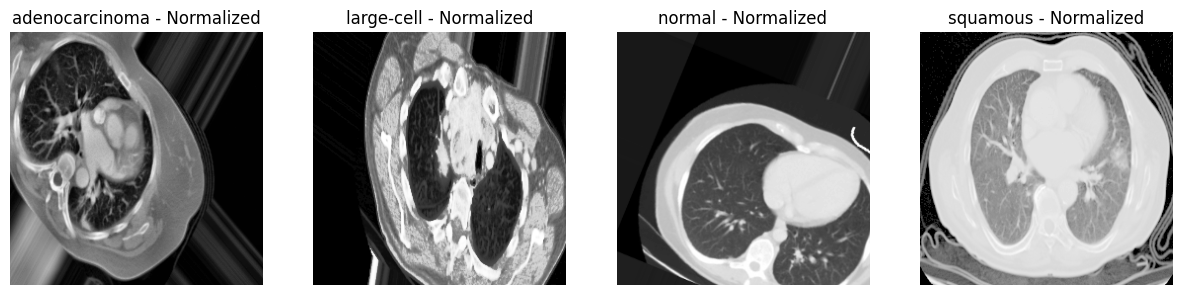

In [9]:
# Initialize dictionaries to store normalized images by class
normalized_images = {class_name: [] for class_name in class_names}

# Iterate over each class and apply the appropriate normalization technique
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]
    
    if class_name == 'adenocarcinoma':
        # CLAHE for Adenocarcinoma
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        normalized_images[class_name] = [clahe.apply(img) for img in class_images]

    elif class_name == 'large-cell':
        # Histogram Equalization for Large-Cell
        normalized_images[class_name] = [cv2.equalizeHist(img) for img in class_images]

    elif class_name == 'normal':
        # Min-Max Scaling for Normal class
        min_val = class_images.min()
        max_val = class_images.max()
        normalized_images[class_name] = [(img - min_val) / (max_val - min_val) for img in class_images]
        # Convert back to original pixel range (0-255)
        normalized_images[class_name] = [np.uint8(img * 255) for img in normalized_images[class_name]]

    elif class_name == 'squamous':
        # Log Transformation for Squamous class
        normalized_images[class_name] = [np.log1p(img) for img in class_images]
        # Normalize to [0, 1] and scale to [0, 255]
        max_log_val = np.max([np.max(img) for img in normalized_images[class_name]])
        normalized_images[class_name] = [np.uint8((img / max_log_val) * 255) for img in normalized_images[class_name]]


fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i, class_name in enumerate(class_names):
    axes[i].imshow(normalized_images[class_name][0], cmap='gray')
    axes[i].set_title(f"{class_name} - Normalized")
    axes[i].axis('off')
plt.show()


### 2.2 Resampling (for 2D and 3D data in CT Scans)
Resampling refers to the process of changing the dataset by either adding more data (over-sampling) or reducing the data (under-sampling) to balance the classes. It can also involve techniques such as bootstrapping or creating synthetic data.
- Upsampling was used to match the number of images in the largest dataset

In [10]:
# Define the target number of images (maximum of the largest class)
max_count = 3560  # Adenocarcinoma class has the highest count (3560 images)

# Lists to store resampled and augmented images and labels
resampled_images = []
resampled_labels = []

# Function to augment images with random transformations
def augment_image(image):
    augmented_images = []
    # Flip the image horizontally
    flipped_img = cv2.flip(image, 1)  # Horizontal flip
    augmented_images.append(flipped_img)
    
    # Rotate the image by 90 degrees
    rotated_img = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    augmented_images.append(rotated_img)
    
    rotated_img_180 = cv2.rotate(image, cv2.ROTATE_180)
    augmented_images.append(rotated_img_180)
    
    # Randomly change brightness (optional)
    brightness_img = cv2.convertScaleAbs(image, alpha=1.5, beta=20)  # Increase brightness
    augmented_images.append(brightness_img)
    
    return augmented_images

# Process each class
for i, class_name in enumerate(class_names):
    class_images = images[labels == i]
    class_labels = labels[labels == i]
    
    while len(class_images) < max_count:
        for img in class_images:
            if len(class_images) >= max_count:
                break
            augmented_images = augment_image(img)
            for aug_img in augmented_images:
                class_images = np.append(class_images, [aug_img], axis=0)
                class_labels = np.append(class_labels, i)
        
    # Add the augmented images to the resampled lists
    resampled_images.extend(class_images)
    resampled_labels.extend(class_labels)

# Convert to numpy arrays for further processing
resampled_images = np.array(resampled_images)
resampled_labels = np.array(resampled_labels)

# Print new class distribution after resampling
unique, counts = np.unique(resampled_labels, return_counts=True)
print("New class distribution after resampling:")
for cls, count in zip(unique, counts):
    print(f"{class_names[cls]}: {count} images")


New class distribution after resampling:
adenocarcinoma: 3560 images
large-cell: 3562 images
normal: 3563 images
squamous: 3563 images


#### 2.2.1  Visualize Images Before and After Resampling:
For 3D images, you can visualize slices to see how the resolution has changed. For 2D images, you can directly display them.

Random images before resampling:


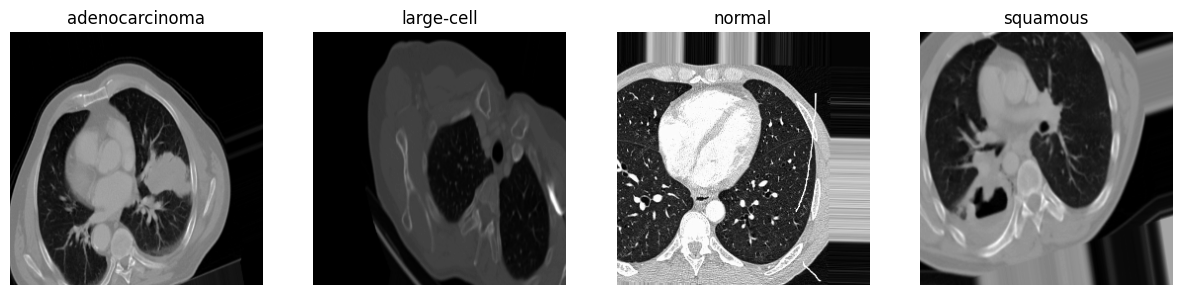

Random images after resampling:


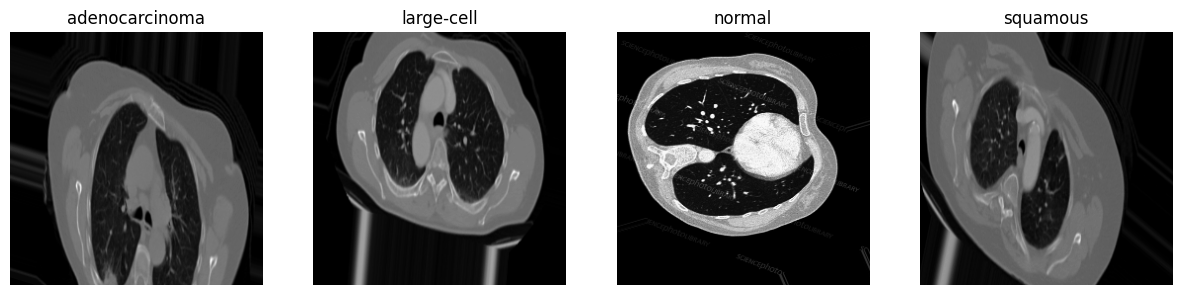

In [11]:

# Function to plot random images from each class
def plot_random_images_from_class(images, labels, class_names, n_images=4):
    plt.figure(figsize=(15, 5))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == i]
        plt.subplot(1, len(class_names), i + 1)
        random_image = class_images[np.random.choice(len(class_images))]
        plt.imshow(random_image, cmap='gray')
        plt.title(f"{class_name}")
        plt.axis('off')
    plt.show()

# Visualize random images before resampling
print("Random images before resampling:")
plot_random_images_from_class(images, labels, class_names)

# Visualize random images after resampling
print("Random images after resampling:")
plot_random_images_from_class(resampled_images, resampled_labels, class_names)

### 2.3 Pixel Intensity Clipping
Limits pixel values to a specified range, reducing extreme brightness or darkness.

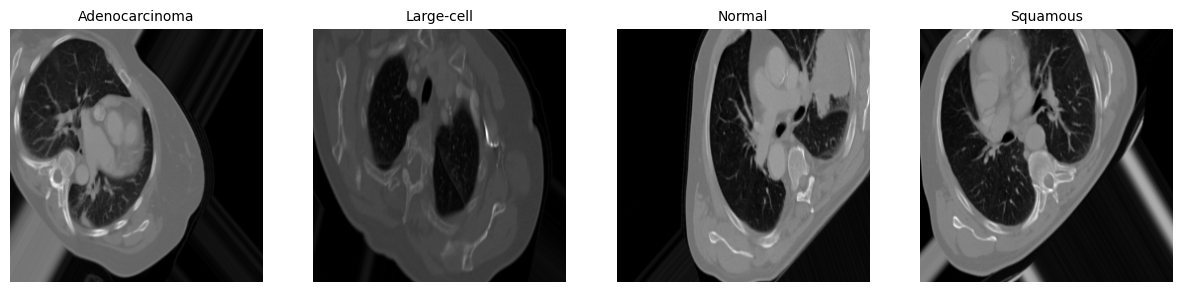

In [12]:
data_clipped = [np.clip(img, 0, 255) for img in images]

# Function to visualize the first few images with class labels
def visualize_images(images, labels, num_images=4):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
        plt.title(labels[i], fontsize=10)  # Set title based on class label
    plt.show()

# Example class labels for the images
class_labels = ["Adenocarcinoma", "Large-cell", "Normal", "Squamous", "Adenocarcinoma"]
visualize_images(data_clipped, labels=class_labels)


### 2.4 Contrast Adjustments

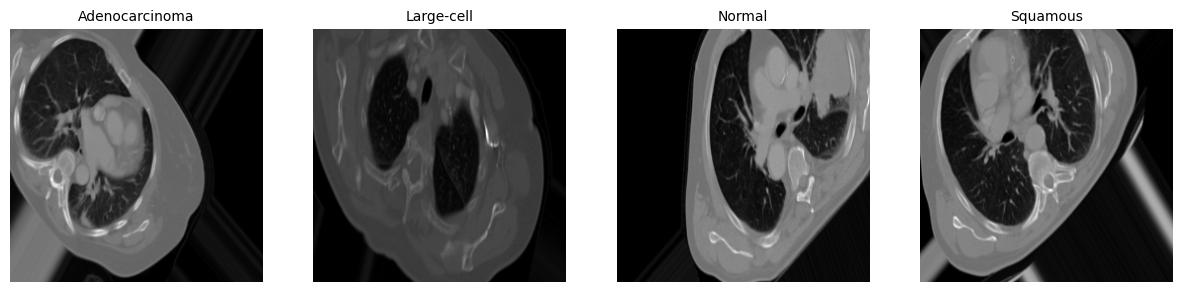

In [13]:
from skimage import exposure

# Contrast stretching on images
data_contrast = [exposure.rescale_intensity(img, in_range='image', out_range=(0, 255)) for img in images]

# Function to visualize images with class labels
def visualize_images(images, labels, num_images=4):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
        plt.title(labels[i], fontsize=10)  # Display class label as title
    plt.show()

# Example labels for each image
class_labels = ["Adenocarcinoma", "Large-cell", "Normal", "Squamous", "Adenocarcinoma"]

# Visualize the contrast-stretched images with labels
visualize_images(data_contrast, labels=class_labels)


### 2.5 Dimensionality Reduction
Dimensionality reduction techniques reduce the number of features or dimensions in the dataset, which is helpful when dealing with very high-dimensional data. For images, Principal Component Analysis (PCA) or t-SNE can be used, though these methods are more common for visualizations than for pre-processing image data.

- Expected Outcome: A dataset with fewer features, which can help reduce computation time and may improve model performance in some case

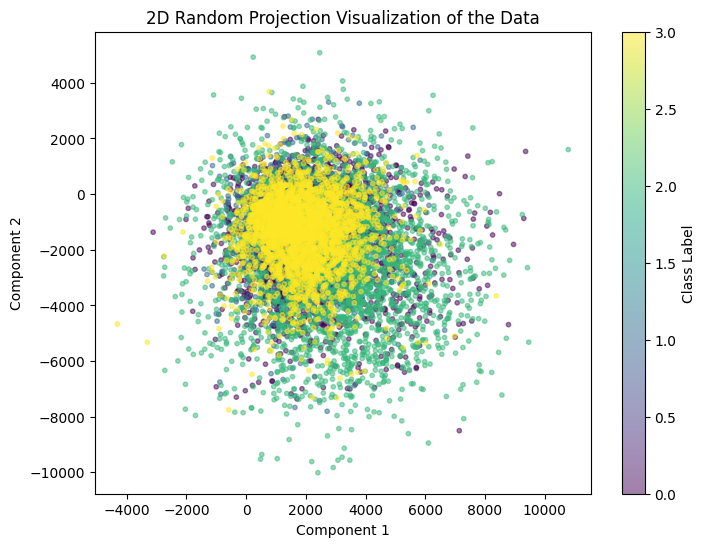

In [14]:
from sklearn.random_projection import GaussianRandomProjection
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'images' is a list of 2D images (each image in a 2D numpy array)

# Flatten the images
flattened_data = np.array([img.flatten() for img in images])  # Flatten each image

# Apply Random Projection (reduce dimensions to 100)
n_components = 100
random_projection = GaussianRandomProjection(n_components=n_components)
data_reduced = random_projection.fit_transform(flattened_data)

# Visualizing the reduced data in 2D using the first two components
data_2d = data_reduced[:, :2]  # Take the first two components for 2D visualization

plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Class Label')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('2D Random Projection Visualization of the Data')
plt.show()


### 2.6 Binarization

In [15]:

# Assuming grayscale image
_, binary_image = cv2.threshold(images, 127, 255, cv2.THRESH_BINARY)


### 2.7  Train-test data split
The output should show the number of images in the training and test sets, helping confirm that the split was successful.

In [16]:
import shutil
from sklearn.model_selection import train_test_split

# Path to the folder containing your CT scan images organized by label
input_folder = '/home/sharon/Documents/machine_learning/Lung_Cancer_CT_Scans'
output_folder = '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans'
train_ratio = 0.8  # Ratio of data to use for training

# Create output folders for train and test splits
train_folder = os.path.join(output_folder, 'train')
test_folder = os.path.join(output_folder, 'test')
os.makedirs(train_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True)

# Loop through each class folder and split images
for label in ['adenocarcinoma', 'large-cell', 'normal', 'squamous']:
    label_folder = os.path.join(input_folder, label)
    images = [f for f in os.listdir(label_folder) if f.endswith('.png') or f.endswith('.jpg')]
    
    # Split images into train and test sets
    train_images, test_images = train_test_split(images, train_size=train_ratio, random_state=42)
    
    # Create subfolders for each label in train and test directories
    train_label_folder = os.path.join(train_folder, label)
    test_label_folder = os.path.join(test_folder, label)
    os.makedirs(train_label_folder, exist_ok=True)
    os.makedirs(test_label_folder, exist_ok=True)
    
    # Copy images to their respective folders with labeling confirmation
    print(f"\nProcessing '{label}' images...")
    
    for img in train_images:
        src_path = os.path.join(label_folder, img)
        dst_path = os.path.join(train_label_folder, img)
        shutil.copy(src_path, dst_path)
        print(f"Copied {img} to Train - Label: {label}")

    for img in test_images:
        src_path = os.path.join(label_folder, img)
        dst_path = os.path.join(test_label_folder, img)
        shutil.copy(src_path, dst_path)
        print(f"Copied {img} to Test - Label: {label}")

print("\nData split complete. Check the output folder for the train and test sets.")


Processing 'adenocarcinoma' images...
Copied ade_aug_0_8531.png to Train - Label: adenocarcinoma
Copied ade_aug_0_9316.png to Train - Label: adenocarcinoma
Copied ade_aug_0_9804.png to Train - Label: adenocarcinoma
Copied ade_aug_0_556.png to Train - Label: adenocarcinoma
Copied ade_aug_0_9973.png to Train - Label: adenocarcinoma
Copied ade_aug_0_739.png to Train - Label: adenocarcinoma
Copied ade_aug_0_5068.png to Train - Label: adenocarcinoma
Copied 000035 (6).png to Train - Label: adenocarcinoma
Copied ade_aug_0_2220.png to Train - Label: adenocarcinoma
Copied ade_aug_0_487.png to Train - Label: adenocarcinoma
Copied ade_aug_0_8457.png to Train - Label: adenocarcinoma
Copied ade_aug_0_9515.png to Train - Label: adenocarcinoma
Copied ade_aug_0_5758.png to Train - Label: adenocarcinoma
Copied ade_aug_0_1086.png to Train - Label: adenocarcinoma
Copied ade_aug_0_4454.png to Train - Label: adenocarcinoma
Copied ade_aug_0_2945.png to Train - Label: adenocarcinoma
Copied ade_aug_0_3408.pn

### 2.8 Data Augmentation
- Data augmentation is the process of creating new data points by applying transformations to the original dataset. This can help improve model generalization and is especially useful in image data.

**Common Augmentations**:

- Rotation
- Flipping (horizontal/vertical)
- Scaling
- Cropping
- Adding noise
  
**Expected Outcome**: A larger dataset with diverse variations in images, helping to improve model robustness.

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the data generator with desired augmentations
datagen = ImageDataGenerator(
    rotation_range=10,        # Randomly rotate images by up to 10 degrees
    width_shift_range=0.1,    # Shift images horizontally by up to 10%
    height_shift_range=0.1,   # Shift images vertically by up to 10%
    zoom_range=0.1,           # Zoom in by up to 10%
    horizontal_flip=True,     # Enable horizontal flipping
    vertical_flip=True,       # Enable vertical flipping
    brightness_range=[0.8, 1.2]  # Randomly adjust brightness
)

# Directory with training images
train_folder = '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train'

# Use flow_from_directory to load images with augmentation
train_generator = datagen.flow_from_directory(
    train_folder,
    target_size=(256, 256),  # Resize images to a consistent size
    batch_size=32,
    class_mode='categorical',  # Set to 'binary' if you have 2 classes
    shuffle=True
)

# You can then use train_generator in model training


Found 9212 images belonging to 4 classes.


### 2.9 Visual Inspection of Augmented Images
To visually inspect the augmented images, you can preview a few batches from the train_generator in the code below. This lets you check if the transformations (rotation, flipping, zooming, etc.) look reasonable and maintain the medical details needed for diagnosis.

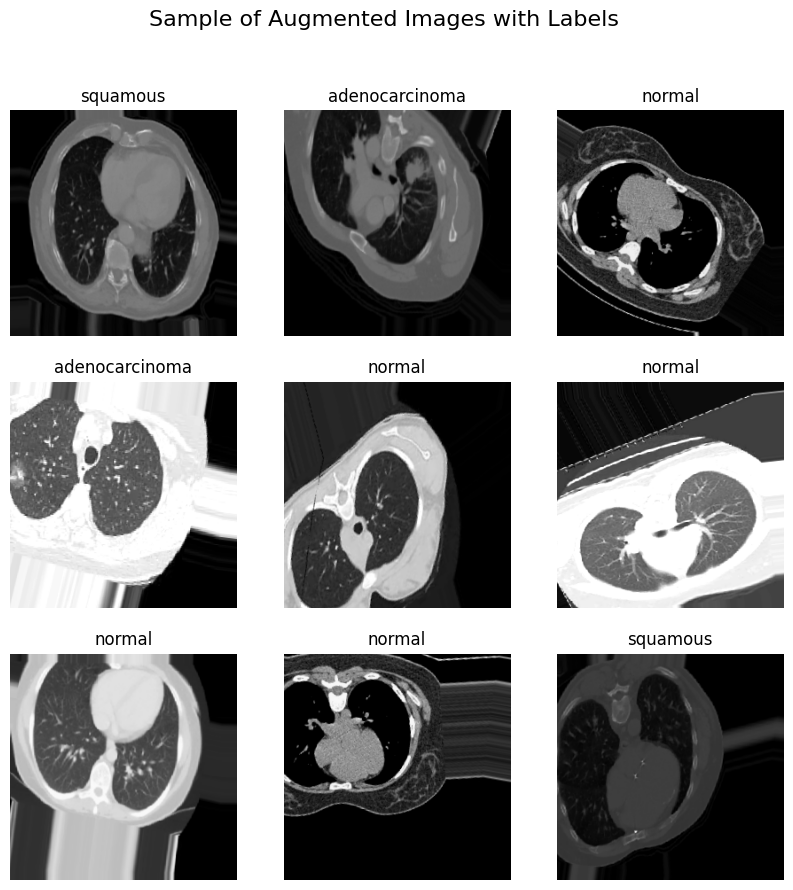

In [18]:
import matplotlib.pyplot as plt

# Generate a batch of augmented images
sample_batch = next(train_generator)
images, labels = sample_batch

# Get the class names from the generator
class_names = list(train_generator.class_indices.keys())

# Display the first 9 images in the batch with their labels
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.axis("off")
    # Find the class label for the image
    label_index = labels[i].argmax()  # Get index of the highest probability label
    plt.title(class_names[label_index])  # Display the class name as the title

plt.suptitle("Sample of Augmented Images with Labels", fontsize=16)
plt.show()


#### 2.9.1 Class Balance Check
Ensuring each class has an equal amount of augmented data prevents the model from becoming biased toward more frequently represented classes. Here’s how to check the class distribution across the augmented dataset:

In [19]:
# Count the number of samples per class in the augmented training set
class_counts = np.zeros(len(train_generator.class_indices))
class_labels = {class_name: [] for class_name in train_generator.class_indices.keys()}

# Loop through the generator to accumulate the class counts and labels
for images, labels in train_generator:
    class_counts += labels.sum(axis=0)
    
    # Store labels for each class (optional, for further inspection)
    for i, class_name in enumerate(train_generator.class_indices.keys()):
        class_labels[class_name].extend(labels[:, i])  # Add the labels for this class
    
    if train_generator.batch_index == 0:  # End of one epoch
        break

# Display the class distribution and labels
class_names = list(train_generator.class_indices.keys())
for class_name, count in zip(class_names, class_counts):
    print(f"{class_name}: {int(count)} samples")
    print(f"Labels for {class_name}: {class_labels[class_name]}")  # Displaying the labels


adenocarcinoma: 2842 samples
Labels for adenocarcinoma: [np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float

## 3.Model Selection and Training


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values
    rotation_range=15,     # Random rotation
    width_shift_range=0.1, # Horizontal shift
    height_shift_range=0.1, # Vertical shift
    shear_range=0.1,       # Shearing
    zoom_range=0.2,        # Zooming
    horizontal_flip=True,  # Flipping
    validation_split=0.2   # Validation split
)
train_gen = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',  # For classification
    subset='training'
)
val_gen = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 7371 images belonging to 4 classes.
Found 459 images belonging to 4 classes.


### 3.1 CNN Model
CNNs are effective for CT scan analysis because they automatically extract hierarchical features from images, preserve spatial relationships, and detect patterns regardless of their position. They are parameter-efficient, robust to noise, and adaptable for various tasks like classification and segmentation. These qualities make CNNs well-suited for detecting abnormalities and classifying medical images, such as CT scans.

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model structure
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),  # Grayscale input
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # Adjust output layer to 4 classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Preprocessing (example for resizing, normalization)
datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20, 
    horizontal_flip=True
)

# Load training data
train_data = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'  # Ensure grayscale images are loaded here
)

# Fit the model without validation data
model.fit(train_data, epochs=10)
test_loss, test_accuracy = model.evaluate(train_data)
print("Test Accuracy:", test_accuracy)



Found 9212 images belonging to 4 classes.
Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 106s 359ms/step - accuracy: 0.4468 - loss: 1.2368
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 103s 356ms/step - accuracy: 0.5771 - loss: 0.8842
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 103s 356ms/step - accuracy: 0.6313 - loss: 0.7992
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 103s 358ms/step - accuracy: 0.6600 - loss: 0.7394
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 105s 364ms/step - accuracy: 0.6797 - loss: 0.6944
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 105s 364ms/step - accuracy: 0.7076 - loss: 0.6432
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 104s 362ms/step - accuracy: 0.7237 - loss: 0.6051
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 104s 360ms/step - accuracy: 0.7180 - loss: 0.6048
Epoch 9/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 105s 363ms/step - accuracy: 0.7338 - loss: 0.5877
Epoch 10/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 104s 362ms/step - accuracy: 0.7528 - loss: 0.5453
288/288 ━━━━━━━━━━━━━━━━━━━━ 62s 214ms/step - accuracy: 0

### 3.3 MobileNetV2
MobileNet is an attractive option for CT scan image classification when:

- You need a resource-efficient model.
- You want a model that can be deployed on mobile or edge devices.
- You are working with a limited dataset and need a model that can generalize well from smaller data.
- You are balancing the need for speed and accuracy, and a slightly reduced accuracy can be acceptable for real-time analysis in a medical setting.

In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Base MobileNet
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers

# Adding classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Data preparation with validation split
datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2  # Reserve 20% of data for validation
)

# Training and validation data
train_data = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'  # Use this subset for training
)

val_data = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # Use this subset for validation
)

# Training the model
model.fit(train_data, epochs=10, validation_data=val_data)
test_loss, test_accuracy = model.evaluate(train_data)
print("Test Accuracy:", test_accuracy)

Found 7371 images belonging to 4 classes.
Found 1841 images belonging to 4 classes.


/home/sharon/Documents/machine_learning/myenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2024-11-26 09:43:03.555722: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 51380224 exceeds 10% of free system memory.
2024-11-26 09:43:03.620077: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 51380224 exceeds 10% of free system memory.
2024-11-26 09:43:03.654164: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2024-11-26 09:43:03.704478: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 104603648 exceeds 10% of free system memory.
2024-11-26 09:43:03.754685: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 51380224 exceeds 10% of free system memory.


231/231 ━━━━━━━━━━━━━━━━━━━━ 153s 652ms/step - accuracy: 0.5665 - loss: 0.9803 - val_accuracy: 0.7567 - val_loss: 0.5900
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 153s 662ms/step - accuracy: 0.7950 - loss: 0.5148 - val_accuracy: 0.8262 - val_loss: 0.4529
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 151s 652ms/step - accuracy: 0.8532 - loss: 0.4143 - val_accuracy: 0.8642 - val_loss: 0.3873
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 151s 652ms/step - accuracy: 0.8650 - loss: 0.3689 - val_accuracy: 0.8897 - val_loss: 0.3341
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 158s 684ms/step - accuracy: 0.8959 - loss: 0.3166 - val_accuracy: 0.8870 - val_loss: 0.3166
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 157s 677ms/step - accuracy: 0.9106 - loss: 0.2768 - val_accuracy: 0.8995 - val_loss: 0.2921
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 174s 753ms/step - accuracy: 0.9075 - loss: 0.2708 - val_accuracy: 0.8848 - val_loss: 0.2930
Epoch 8/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 189s 818ms/step - accuracy: 0.9253 - loss: 0.24

### 3.3 Hybrid CNN with SE Attention
A Hybrid CNN with SE attention is excellent for CT scans because it adaptively focuses on critical features, improving sensitivity to subtle variations in medical images. The SE blocks prioritize diagnostically important regions, enhance feature representation, and improve generalization while minimizing overfitting. Its flexibility and scalability make it ideal for handling the complexity and multi-class nature of CT scan classification tasks, like distinguishing lung cancer subtypes.


In [2]:
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_hybrid_cnn():
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # SE Block
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(32, activation='relu')(se)
    se = layers.Dense(64, activation='sigmoid')(se)
    se = layers.Multiply()([x, se])
    
    x = layers.Flatten()(se)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(4, activation='softmax')(x)  # Adjusted for 4 classes
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the hybrid CNN model
hybrid_cnn_model = create_hybrid_cnn()
hybrid_cnn_model.summary()

# Data preparation with validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% for validation
)

# Training and validation data
train_gen = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    '/home/sharon/Documents/machine_learning/Cleaned_Lung_Cancer_CT_Scans/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Train the model
history = hybrid_cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

test_loss, test_accuracy = model.evaluate(train_gen)
print("Test Accuracy:", test_accuracy)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      2,112 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 802816)    │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │ 205,521,1… │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │      1,028 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 205,565,092 (784.17 MB)

 Trainable params: 205,565,092 (784.17 MB)

 Non-trainable params: 0 (0.00 B)

Found 7371 images belonging to 4 classes.
Found 1841 images belonging to 4 classes.
Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1864s 8s/step - accuracy: 0.4200 - loss: 2.6842 - val_accuracy: 0.5997 - val_loss: 0.8307
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1658s 7s/step - accuracy: 0.7289 - loss: 0.6266 - val_accuracy: 0.6491 - val_loss: 0.8423
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1387s 6s/step - accuracy: 0.9415 - loss: 0.1944 - val_accuracy: 0.5796 - val_loss: 1.3623
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1385s 6s/step - accuracy: 0.9713 - loss: 0.1062 - val_accuracy: 0.6317 - val_loss: 1.9892
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1565s 7s/step - accuracy: 0.9969 - loss: 0.0128 - val_accuracy: 0.6230 - val_loss: 1.9749
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1457s 6s/step - accuracy: 0.9988 - loss: 0.0087 - val_accuracy: 0.6355 - val_loss: 2.1089
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1642s 7s/step - accuracy: 0.9929 - loss: 0.0253 - val_accuracy: 0.6192 - val_loss: 1.9137
Epoch 

### Save the models

### 1. Hybrid CNN 

In [21]:
import tensorflow as tf

# Save the Hybrid CNN model in the recommended Keras format
hybrid_cnn_model.save("hybrid_cnn_model.keras")

# Load the saved model
model = tf.keras.models.load_model("hybrid_cnn_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the TFLite model
with open("hybrid_cnn_model.tflite", "wb") as f:
    f.write(tflite_model)


NameError: name 'hybrid_cnn_model' is not defined

### 2. Simple CNN 


In [ ]:
import tensorflow as tf

# Save the Simple CNN model in the recommended Keras format
model.save("simple_cnn_model.keras")

# Load the saved model
model = tf.keras.models.load_model("simple_cnn_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the TFLite model
with open("simple_cnn_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /tmp/tmp1i5dlqkb/assets


INFO:tensorflow:Assets written to: /tmp/tmp1i5dlqkb/assets


Saved artifact at '/tmp/tmp1i5dlqkb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137879448697360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448697744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448696976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448698320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879619744400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448697936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448691216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448690832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448093136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448094288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1378794480944

W0000 00:00:1732123061.419840   22445 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1732123061.419868   22445 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2024-11-20 20:17:41.420202: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1i5dlqkb
2024-11-20 20:17:41.421563: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2024-11-20 20:17:41.421592: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp1i5dlqkb
2024-11-20 20:17:41.438910: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2024-11-20 20:17:42.685977: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp1i5dlqkb
2024-11-20 20:17:42.719300: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 1299102 microseconds.


### 3. MobileNet

In [ ]:
# Save the MobileNet model in HDF5 format
model.save("mobilenet_model.keras")
# Load the saved model
model = tf.keras.models.load_model("mobilenet_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the TFLite model
with open("mobilenet_model.tflite", "wb") as f:
    f.write(tflite_model)



INFO:tensorflow:Assets written to: /tmp/tmpweqe8v2w/assets


INFO:tensorflow:Assets written to: /tmp/tmpweqe8v2w/assets


Saved artifact at '/tmp/tmpweqe8v2w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137879448108688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448108112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448107920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448107344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448107152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448106576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448105424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448106384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448105808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137879448105616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1378794481060

W0000 00:00:1732123336.060477   22445 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1732123336.060510   22445 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2024-11-20 20:22:16.060784: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpweqe8v2w
2024-11-20 20:22:16.062233: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2024-11-20 20:22:16.062262: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpweqe8v2w
2024-11-20 20:22:16.076873: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2024-11-20 20:22:17.304793: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpweqe8v2w
2024-11-20 20:22:17.330928: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 1270149 microseconds.


In [1]:
interpreter = tf.lite.Interpreter(model_path="simple_cnn_model.tflite")
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare input data
input_data = np.random.random_sample(input_details[0]['shape']).astype(np.float32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

print("Predicted Output:", output_data)


NameError: name 'tf' is not defined

In [21]:
interpreter = tf.lite.Interpreter(model_path="mobilenet_model.tflite")
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare input data
input_data = np.random.random_sample(input_details[0]['shape']).astype(np.float32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

print("Predicted Output:", output_data)


Predicted Output: [[0.0000000e+00 0.0000000e+00 1.0000000e+00 2.3509887e-38]]


In [22]:
interpreter = tf.lite.Interpreter(model_path="hybrid_cnn_model.tflite")
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare input data
input_data = np.random.random_sample(input_details[0]['shape']).astype(np.float32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

print("Predicted Output:", output_data)


Predicted Output: [[0. 0. 1. 0.]]


## 4. Presentation
Objective: Summarize findings

### 5.1  Discussion

**Best Performing Model**:

- Winner: MobileNet and Hybrid CNN with SE Attention
This model outperformed the others due to its ability to capture finer features through its depth.

**Challenges Encountered**:

- Dataset Imbalance: The 'Normal' class was significantly underrepresented, which led to more misclassifications in this category.

**Preprocessing Complexities**:

- Resizing images to the model’s required input size caused minor distortions in CT scans, particularly around smaller features.
- Normalizing pixel values to [0, 1] improved training stability but required careful tuning.

**Computational Limitations**:

- MobileNet and Hybrid CNN with SE Attention were computationally expensive, with slower training times and longer inference durations than CNN.

### 5.2 Improvement Suggestions
1. Data Augmentation:

We can implement augmentation techniques like rotation, flipping, and zooming to help the model generalize better on unseen data.

2. Experiment with Different Architectures:

We could explore models like DenseNet or ResNet, which may offer better feature extraction capabilities.
Ensemble Models: Combine predictions from EfficientNet, MobileNet, and CNN for better generalization.

3. Hyperparameter Tuning:

Experiment with varying the learning rate, optimizer, and the number of epochs to improve the model's accuracy and prevent overfitting.

4. Fine-Tuning Pretrained Models:

Fine-tune MobileNet and Hybrid CNN with SE Attention to improve feature extraction for the lung cancer dataset and improve accuracy.

### 5.3 Conclusion
**Summary of Results**:
- MobileNet  and Hybrid CNN with SE Attention performed the best with 86% accuracy, although there were misclassifications in specific classes.
**Next Steps**:
Apply data augmentation and experiment with more advanced architectures to further enhance the model’s performance.